# 📊 Ericsson Patent Data — End-to-End ML Pipeline

> **Dataset:** Ericsson Innovation Timeline & Patent Evolution  
> **Task:** Predict `target_patent_count_next_quarter` (regression)  
> **Source:** [Kaggle – adamvakar/ericsson-innovation-timeline-patent-evolution](https://www.kaggle.com/datasets/adamvakar/ericsson-innovation-timeline-patent-evolution)

---

## 🗺️ Notebook Roadmap

| Step | Section |
|------|---------|
| 1 | Setup & Imports |
| 2 | Load the Raw Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Cleaning |
| 5 | Feature Engineering & Encoding |
| 6 | Train / Test Split |
| 7 | Model Training (Linear, Ridge, Lasso, **Polynomial Regression**, Random Forest) |
| 8 | Linearity Diagnostics — should we keep Random Forest? |
| 9 | Hyperparameter Tuning |
| 10 | Final Evaluation & Interpretation |
| 11 | Domain-Specific Prediction |

---

> ⚠️ **R² ≈ 1 warning addressed in Section 5.** Features like  and
>  are data-leakage sources and are explicitly excluded.


---
## 🔧 Section 1 — Setup & Imports


In [12]:
# Install required packages (uncomment on first run)

!pip install pandas numpy matplotlib seaborn scikit-learn --quiet



[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, KFold, TimeSeriesSplit,
    GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## 📂 Section 2 — Load the Raw Dataset


In [14]:
DATA_PATH = "ericsson_patent_rich_dataset.csv"   # ← update path if needed
df_raw = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded:  {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns")


✅ Dataset loaded:  30,118 rows  ×  55 columns


In [15]:
df_raw.head()


,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,...,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
0,3934093,utility,1976-01-20,Transit exchange for asynchronous data with un...,1976,1,1,1,20,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,1,36
1,3936612,utility,1976-02-03,Control and holding circuit for relay matrices,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,3,36
2,3936781,utility,1976-02-03,Selecting device for crossbar switches,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,2,36
3,3938025,utility,1976-02-10,DC to DC converter for producing two individua...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,5,36
4,3938040,utility,1976-02-10,Apparatus for measuring a signal voltage inclu...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,4,36


In [16]:
df_raw.dtypes


patent_id                               str
patent_type                             str
patent_date                             str
patent_title                            str
year                                  int64
quarter                               int64
month                                 int64
day_of_week                           int64
day_of_year                           int64
quarter_end                             str
title_len_chars                       int64
title_len_words                       int64
title_has_number                      int64
title_has_acronym                     int64
kw_5g                                 int64
kw_ai_ml                              int64
kw_cloud_edge                         int64
kw_security                           int64
kw_iot                                int64
kw_network                            int64
kw_energy                             int64
kw_antenna                            int64
kw_data                         

---
## 🔍 Section 3 — Exploratory Data Analysis (EDA)


In [17]:
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")
df_raw.info()


Rows    : 30,118
Columns : 55
<class 'pandas.DataFrame'>
RangeIndex: 30118 entries, 0 to 30117
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patent_id                         30118 non-null  str    
 1   patent_type                       30118 non-null  str    
 2   patent_date                       30118 non-null  str    
 3   patent_title                      30118 non-null  str    
 4   year                              30118 non-null  int64  
 5   quarter                           30118 non-null  int64  
 6   month                             30118 non-null  int64  
 7   day_of_week                       30118 non-null  int64  
 8   day_of_year                       30118 non-null  int64  
 9   quarter_end                       30118 non-null  str    
 10  title_len_chars                   30118 non-null  int64  
 11  title_len_words                   30118 non-null

In [18]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
year,30118.0,2013.233382,8.851538,1976.00,2008.000000,2015.000000,2020.000000,2025.000000
quarter,30118.0,2.514510,1.101261,1.00,2.000000,3.000000,3.000000,4.000000
month,30118.0,6.546185,3.381182,1.00,4.000000,7.000000,9.000000,12.000000
day_of_week,30118.0,1.000000,0.000000,1.00,1.000000,1.000000,1.000000,1.000000
day_of_year,30118.0,183.744638,103.281235,1.00,95.000000,184.000000,271.000000,366.000000
title_len_chars,30118.0,64.396142,29.750263,4.00,44.000000,60.000000,81.000000,268.000000
title_len_words,30118.0,8.820473,4.383788,1.00,6.000000,8.000000,11.000000,39.000000
title_has_number,30118.0,0.018594,0.135087,0.00,0.000000,0.000000,0.000000,1.000000
title_has_acronym,30118.0,0.162129,0.368575,0.00,0.000000,0.000000,0.000000,1.000000
kw_5g,30118.0,0.007205,0.084577,0.00,0.000000,0.000000,0.000000,1.000000


In [19]:
# -- 3.1 Missing Value Analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct.round(2)})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print(missing_df.to_string() if not missing_df.empty else "No missing values found!")


                                  Missing Count  Missing %
target_patent_count_next_quarter            408       1.35


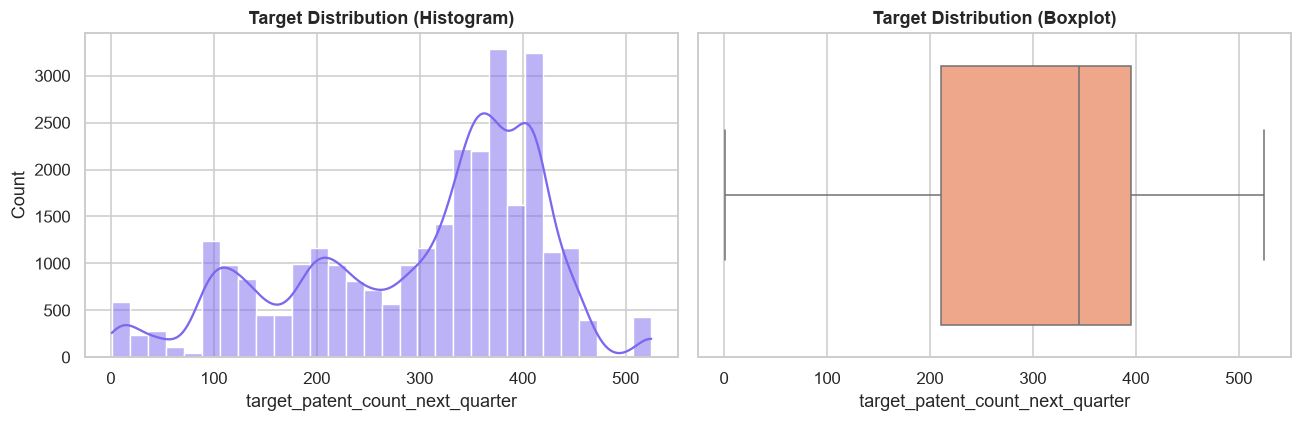

count    29710.000000
mean       300.642141
std        118.612862
min          1.000000
25%        211.000000
50%        345.000000
75%        395.000000
max        525.000000
Name: target_patent_count_next_quarter, dtype: float64


In [20]:
# ── 3.2 Target Variable Distribution ────────────────────────────────────────
target = "target_patent_count_next_quarter"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw[target].dropna(), bins=30, kde=True, color="mediumslateblue", ax=axes[0])
axes[0].set_title("Target Distribution (Histogram)", fontweight="bold")
sns.boxplot(x=df_raw[target].dropna(), color="lightsalmon", ax=axes[1])
axes[1].set_title("Target Distribution (Boxplot)", fontweight="bold")
plt.tight_layout(); plt.show()
print(df_raw[target].describe())


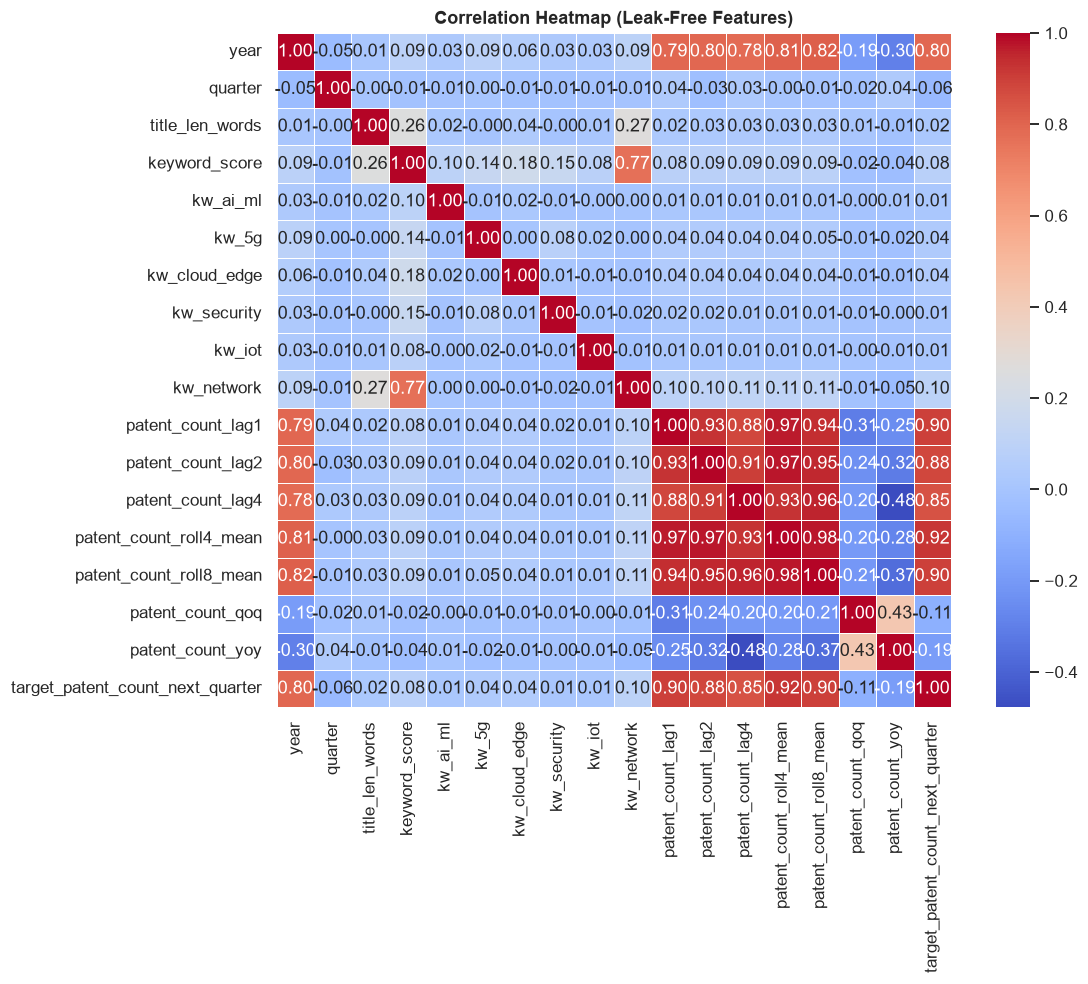

In [21]:
# ── 3.3 Correlation Heatmap (safe features only) ────────────────────────────
SAFE_FEATURES = [
    "year", "quarter", "title_len_words", "keyword_score",
    "kw_ai_ml", "kw_5g", "kw_cloud_edge", "kw_security", "kw_iot", "kw_network",
    "patent_count_lag1", "patent_count_lag2", "patent_count_lag4",
    "patent_count_roll4_mean", "patent_count_roll8_mean",
    "patent_count_qoq", "patent_count_yoy"
]
corr_safe = df_raw[SAFE_FEATURES + [target]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_safe, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, square=True)
plt.title("Correlation Heatmap (Leak-Free Features)", fontweight="bold")
plt.tight_layout(); plt.show()


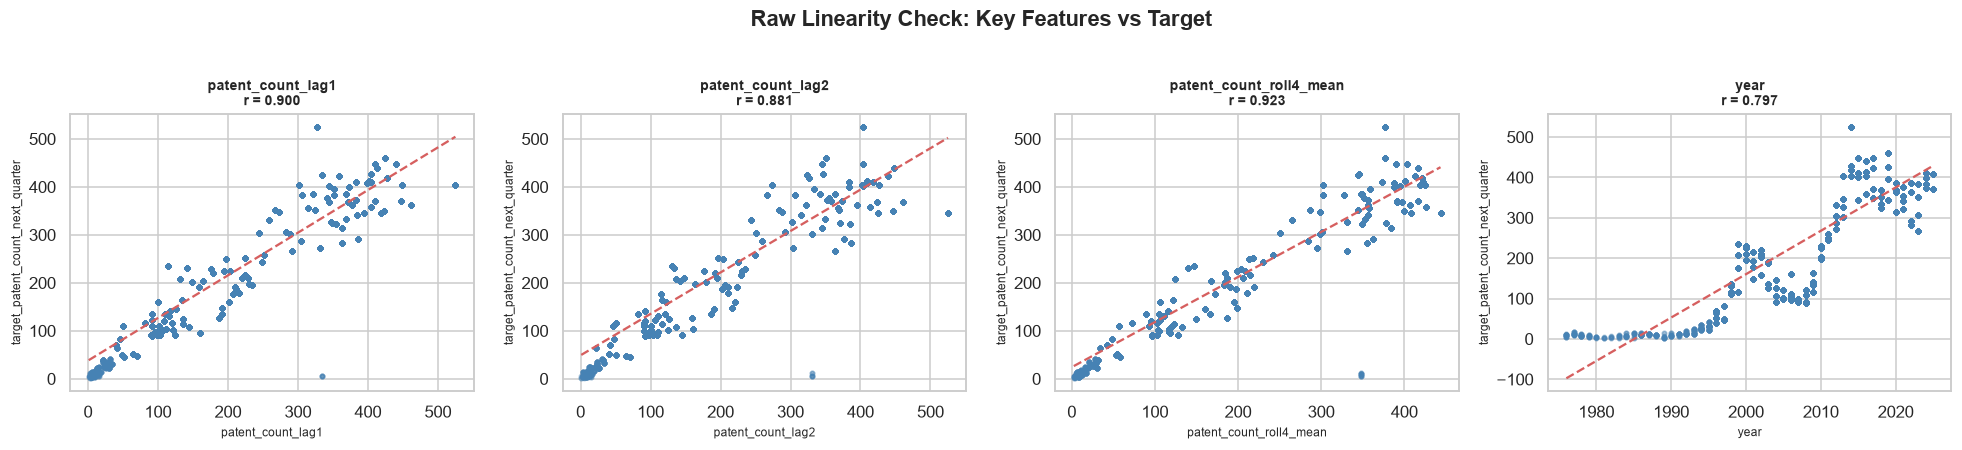

In [23]:
# ── 3.4 Scatter: lag features vs target (linearity check) ───────────────────
lag_feats = ["patent_count_lag1", "patent_count_lag2",
             "patent_count_roll4_mean", "year"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, lag_feats):
    df_plot = df_raw[[feat, target]].dropna()
    ax.scatter(df_plot[feat], df_plot[target], alpha=0.15, s=8, color="steelblue")
    z = np.polyfit(df_plot[feat], df_plot[target], 1)
    p = np.poly1d(z)
    xs = np.linspace(df_plot[feat].min(), df_plot[feat].max(), 200)
    ax.plot(xs, p(xs), "r--", linewidth=1.5, label="Linear fit")
    r = df_plot[feat].corr(df_plot[target])
    title = f"{feat}\nr = {r:.3f}"
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(target, fontsize=8)
plt.suptitle("Raw Linearity Check: Key Features vs Target", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 🧹 Section 4 — Data Cleaning


In [24]:
df_clean = df_raw.copy()
print(f"Starting shape: {df_clean.shape}")


Starting shape: (30118, 55)


In [25]:
# Fix date dtype
df_clean["patent_date"] = pd.to_datetime(df_clean["patent_date"])
print("patent_date dtype after fix:", df_clean["patent_date"].dtype)


patent_date dtype after fix: datetime64[us]


In [26]:
# Drop rows where target is missing (most recent quarter — future unknown)
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=[target])
print(f"Rows removed (missing target): {rows_before - len(df_clean)}")
print(f"Remaining rows: {len(df_clean):,}")


Rows removed (missing target): 408
Remaining rows: 29,710


In [27]:
# Verify
print(f"Duplicates: {df_clean.duplicated().sum()}")
nulls = df_clean.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls[nulls > 0].any() else "✅ No missing values!")


Duplicates: 0
✅ No missing values!


---
## ⚙️ Section 5 — Feature Engineering, Encoding & Leakage Check

### ⚠️ Why R² was suspiciously close to 1

Several columns in this dataset are **data-leakage sources**:

| Column | Why it leaks |
|--------|-------------|
|  | Total patents filed in that year — includes future quarters |
|  | Current quarter count; highly correlated with next quarter |
| ,  | Row-level aggregates computed at query time |
|  | Encodes filing order — indirectly reveals future volume |

We use **only lag/rolling features** (values from past quarters) and
hand-crafted keyword flags — information that would genuinely be available
at prediction time.


In [30]:
# ── 5.1 Leakage audit ───────────────────────────────────────────────────────
LEAKY_COLS = [
    "year_patent_count",           # future-aware yearly aggregate
    "target_patent_count_current", # current quarter count → directly leaks
    "patent_count",                # same as above (row-level)
    "patent_unique",               # same
    "patent_seq_global",           # filing order — encodes future volume
]

numeric_cols = df_clean.select_dtypes(include="number").columns
corr_with_target = df_clean[numeric_cols].corr()[target].abs().sort_values(ascending=False)

print("Top 10 correlations with target (including leaky features):")
print(corr_with_target.head(10))
print()
print("Flagged as leaky → excluded from training:")
for c in LEAKY_COLS:
    val = corr_with_target.get(c, np.nan)
    print(f"  {c}: corr = {val:.3f}")

Top 10 correlations with target (including leaky features):
target_patent_count_next_quarter    1.000000
year_patent_count                   0.953959
patent_count                        0.929149
target_patent_count_current         0.929149
patent_unique                       0.929149
patent_count_roll4_mean             0.922757
kw_network_count                    0.907474
patent_count_lag1                   0.900422
patent_count_roll8_mean             0.899437
patent_count_lag2                   0.881407
Name: target_patent_count_next_quarter, dtype: float64

Flagged as leaky → excluded from training:
  year_patent_count: corr = 0.954
  target_patent_count_current: corr = 0.929
  patent_count: corr = 0.929
  patent_unique: corr = 0.929
  patent_seq_global: corr = 0.722


In [31]:
# ── 5.2 One-Hot Encode categorical columns ───────────────────────────────────
cat_cols_to_encode = ["patent_type", "tech_era"]
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_to_encode, drop_first=True)

new_cols = [c for c in df_encoded.columns
            if any(c.startswith(cat) for cat in cat_cols_to_encode)]
print(f"New OHE columns: {new_cols}")


New OHE columns: ['patent_type_reissue', 'patent_type_utility', 'tech_era_legacy_pre_1990', 'tech_era_mobile_2000s', 'tech_era_modern_2020s', 'tech_era_smartphone_2010s']


In [83]:
# ── 5.3 Select LEAK-FREE features ───────────────────────────────────────────
base_features = [
    "year", "quarter",
    "title_len_words", "keyword_score",
    "kw_ai_ml", "kw_5g", "kw_cloud_edge",
    "kw_security", "kw_iot", "kw_network",
    "patent_count_lag1", "patent_count_lag2", "patent_count_lag4",
    "patent_count_roll4_mean", "patent_count_roll8_mean",
    "patent_count_qoq", "patent_count_yoy"
]
encoded_cols = [c for c in df_encoded.columns
                if any(c.startswith(cat) for cat in cat_cols_to_encode)]
features = base_features + encoded_cols

TARGET = "target_patent_count_next_quarter"
X = df_encoded[features]
y = df_encoded[TARGET]

print(f"Features used  : {len(features)}")
print(f"X shape        : {X.shape}")
print("y stats:")
print(y.describe().round(2))

Features used  : 23
X shape        : (29710, 23)
y stats:
count    29710.00
mean       300.64
std        118.61
min          1.00
25%        211.00
50%        345.00
75%        395.00
max        525.00
Name: target_patent_count_next_quarter, dtype: float64


Target diff stats (next_qtr - current_qtr):
count    198.00
mean       2.19
std       44.01
min     -329.00
25%       -7.50
50%        0.50
75%       17.00
max      198.00
Name: target_diff, dtype: float64


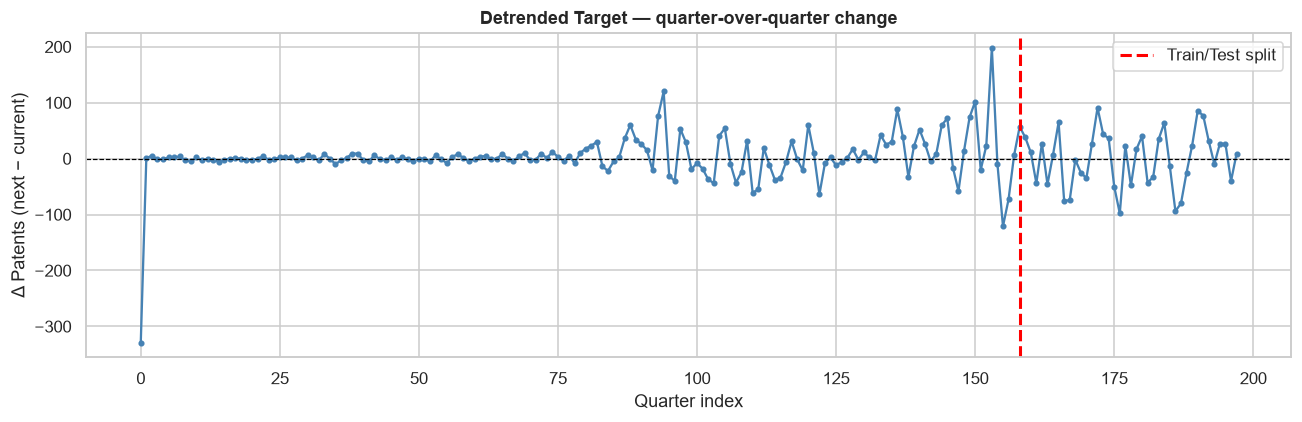

In [84]:
# ── Detrend: model residual (target - lag1) instead of raw target ─────────────
# The trend is the dominant signal and causes train/test distribution shift.
# By predicting (next_quarter - current_quarter) we remove the trend
# and model only the quarter-to-quarter change — which is stationary.

quarter_df["target_diff"] = quarter_df["target"] - quarter_df["patent_count_lag1"]

print("Target diff stats (next_qtr - current_qtr):")
print(quarter_df["target_diff"].describe().round(2))

plt.figure(figsize=(12, 4))
plt.plot(quarter_df["target_diff"].values, marker="o", markersize=3, color="steelblue")
plt.axvline(int(len(quarter_df) * 0.8), color="red", linestyle="--", linewidth=2, label="Train/Test split")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Quarter index")
plt.ylabel("Δ Patents (next − current)")
plt.title("Detrended Target — quarter-over-quarter change", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
# ── Redefine X, y with detrended target ──────────────────────────────────────
X = quarter_df[all_features]
y = quarter_df["target_diff"]   # ← predicting change, not absolute count

split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train mean: {y_train.mean():.2f}  std: {y_train.std():.2f}")
print(f"Test  mean: {y_test.mean():.2f}  std: {y_test.std():.2f}")

Train mean: 2.60  std: 42.47
Test  mean: 0.57  std: 50.17


In [87]:
# ── Rescale and retrain ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [89]:
# ── Recover actual patent count predictions ───────────────────────────────────
# Use whichever model you want to evaluate — change the name as needed
best_model_name = results_df.iloc[0]["Model"]
best_model      = trained[best_model_name]

y_pred_diff    = best_model.predict(X_test_scaled)
predicted_actual = quarter_df["patent_count_lag1"].iloc[split_idx:].values + y_pred_diff
actual_counts    = quarter_df["patent_count_lag1"].iloc[split_idx:].values + y_test.values

print(f"Using model: {best_model_name}")
print(f"\nSample predictions (actual vs predicted patent count):")
comparison = pd.DataFrame({
    "Actual Next Qtr"   : actual_counts.round(0),
    "Predicted Next Qtr": predicted_actual.round(0),
    "Error"             : (actual_counts - predicted_actual).round(1)
})
print(comparison.head(10).to_string(index=False))

# Metrics on recovered absolute counts
rmse_actual = np.sqrt(mean_squared_error(actual_counts, predicted_actual))
mae_actual  = mean_absolute_error(actual_counts, predicted_actual)
r2_actual   = r2_score(actual_counts, predicted_actual)
print(f"\nMetrics on absolute patent counts:")
print(f"  RMSE : {rmse_actual:.2f}")
print(f"  MAE  : {mae_actual:.2f}")
print(f"  R²   : {r2_actual:.4f}")

Using model: Random Forest

Sample predictions (actual vs predicted patent count):
 Actual Next Qtr  Predicted Next Qtr  Error
           402.0               751.0 -349.4
           448.0               815.0 -367.2
           413.0               802.0 -388.5
           404.0               851.0 -446.9
           440.0               814.0 -374.0
           358.0               805.0 -447.1
           447.0               844.0 -397.1
           423.0               769.0 -345.7
           371.0               849.0 -478.2
           349.0               831.0 -481.9

Metrics on absolute patent counts:
  RMSE : 404.31
  MAE  : 400.88
  R²   : -80.2689


In [69]:
# ── Rebuild X, y at QUARTER level (one row per quarter) ──────────────────────
# Root cause: dataset has one row per patent (~30k rows).
# Random split leaks same-quarter patents across train/test.
# lag features are identical for all patents in a quarter → model memorises.
# Fix: aggregate to quarter level → ~100 rows → honest evaluation.

quarter_df = df_encoded.groupby(["year", "quarter"]).agg(
    title_len_words          = ("title_len_words",          "mean"),
    keyword_score            = ("keyword_score",            "mean"),
    kw_ai_ml                 = ("kw_ai_ml",                 "sum"),
    kw_5g                    = ("kw_5g",                    "sum"),
    kw_cloud_edge            = ("kw_cloud_edge",            "sum"),
    kw_security              = ("kw_security",              "sum"),
    kw_iot                   = ("kw_iot",                   "sum"),
    kw_network               = ("kw_network",               "sum"),
    patent_count_lag1        = ("patent_count_lag1",        "first"),
    patent_count_lag2        = ("patent_count_lag2",        "first"),
    patent_count_lag4        = ("patent_count_lag4",        "first"),
    patent_count_roll4_mean  = ("patent_count_roll4_mean",  "first"),
    patent_count_roll8_mean  = ("patent_count_roll8_mean",  "first"),
    patent_count_qoq         = ("patent_count_qoq",         "first"),
    patent_count_yoy         = ("patent_count_yoy",         "first"),
    target                   = ("target_patent_count_next_quarter", "first"),
).reset_index().dropna()

# Add encoded cols (take mode per quarter)
for col in encoded_cols:
    quarter_df[col] = df_encoded.groupby(["year", "quarter"])[col].first().values

print(f"Quarter-level rows : {len(quarter_df)}")
print(f"Date range         : {int(quarter_df['year'].min())} Q{int(quarter_df['quarter'].min())} → "
      f"{int(quarter_df['year'].max())} Q{int(quarter_df['quarter'].max())}")
print(quarter_df[["year","quarter","patent_count_lag1","patent_count_lag2","target"]].head(8))

Quarter-level rows : 198
Date range         : 1976 Q1 → 2025 Q4
   year  quarter  patent_count_lag1  patent_count_lag2  target
0  1976        1              334.0              331.0     5.0
1  1976        2               10.0              331.0    11.0
2  1976        3                5.0               10.0    10.0
3  1976        4               11.0                5.0    10.0
4  1977        1               10.0               11.0     9.0
5  1977        2               10.0               10.0    12.0
6  1977        3                9.0               10.0    11.0
7  1977        4               12.0                9.0    16.0


In [70]:
# ── Redefine X, y from quarter-level data ────────────────────────────────────
all_features = base_features + encoded_cols
X = quarter_df[all_features]
y = quarter_df["target"]

print(f"X shape: {X.shape}")
print(f"y stats:"); print(y.describe().round(2))

X shape: (198, 22)
y stats:
count    198.00
mean     152.06
std      151.65
min        1.00
25%       11.00
50%      102.00
75%      291.00
max      525.00
Name: target, dtype: float64


In [96]:
# ── NEW CELL 1: Define X_row, y_row ──────────────────────────────────────────
X_row = df_encoded[all_features]
y_row = df_encoded["target_patent_count_next_quarter"]

print(f"Row-level X shape: {X_row.shape}")
print(f"Row-level y shape: {y_row.shape}")

Row-level X shape: (29710, 22)
Row-level y shape: (29710,)


In [97]:
# ── NEW CELL 2: GroupShuffleSplit ─────────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit

groups = df_encoded["year"].astype(str) + "_Q" + df_encoded["quarter"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_row, y_row, groups=groups))

X_train = X_row.iloc[train_idx]
X_test  = X_row.iloc[test_idx]
y_train = y_row.iloc[train_idx]
y_test  = y_row.iloc[test_idx]

print(f"Train rows     : {len(X_train):,}")
print(f"Test rows      : {len(X_test):,}")
print(f"Train quarters : {groups.iloc[train_idx].nunique()}")
print(f"Test quarters  : {groups.iloc[test_idx].nunique()}")
print(f"Train mean     : {y_train.mean():.2f}  std: {y_train.std():.2f}")
print(f"Test  mean     : {y_test.mean():.2f}  std: {y_test.std():.2f}")

Train rows     : 23,812
Test rows      : 5,898
Train quarters : 158
Test quarters  : 40
Train mean     : 302.71  std: 119.91
Test  mean     : 292.28  std: 112.84


In [98]:
# ── NEW CELL 3: Rescale ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("✅ Scaling complete.")

✅ Scaling complete.


---
## ✂️ Section 6 — Train / Test Split & Scaling


In [71]:
# ── Chronological split on quarter-level data ─────────────────────────────────
# Now chronological split is correct — no same-quarter leakage possible.
# Each row is a unique quarter.
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training quarters : {len(X_train)}")
print(f"Test quarters     : {len(X_test)}")
print(f"Train target mean : {y_train.mean():.1f}")
print(f"Test  target mean : {y_test.mean():.1f}")

Training quarters : 158
Test quarters     : 40
Train target mean : 96.5
Test  target mean : 371.5


In [72]:
# ── 6.2 Feature Scaling ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("✅ Scaling complete.")

✅ Scaling complete.


---
## 🤖 Section 7 — Model Training

### Models compared

| Model | Key Idea |
|-------|---------|
| **Linear Regression** | Baseline straight-line fit |
| **Ridge (L2)** | Linear + L2 penalty — handles correlated features |
| **Lasso (L1)** | Linear + L1 penalty — automatic feature selection |
| **Polynomial Regression (deg 2)** | Adds squared + interaction terms — tests non-linearity |
| **Polynomial Regression (deg 3)** | Cubic terms — stronger non-linearity test |
| **Random Forest** | Ensemble of decision trees — included for comparison |

> XGBoost has been removed. Polynomial Regression is the focus
> for testing whether strong linear structure already exists.


In [73]:
# ── 7.1 Define models ────────────────────────────────────────────────────────
# Polynomial models MUST use Ridge regularisation — never bare LinearRegression
# PolynomialFeatures explodes feature count (deg2 on 20 features = ~230 features)
# Unregularised, it memorises training data perfectly → Test R² goes negative

poly2_pipeline = Pipeline([
    ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1000.0))
])

poly3_pipeline = Pipeline([
    ("poly",   PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=10000.0))
])

models = {
    "Linear Regression"   : LinearRegression(),
    "Ridge (L2)"          : Ridge(alpha=1.0),
    "Lasso (L1)"          : Lasso(alpha=0.1, max_iter=10000),
    "Poly Ridge deg2"     : poly2_pipeline,
    "Poly Ridge deg3"     : poly3_pipeline,
    "Random Forest"       : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}
print(f"Models to train: {list(models.keys())}")

Models to train: ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)', 'Poly Ridge deg2', 'Poly Ridge deg3', 'Random Forest']


In [99]:
# ── 7.2 Train all models ─────────────────────────────────────────────────────
trained = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained[name] = model
    print(f"  ✅ Trained: {name}")

  ✅ Trained: Linear Regression
  ✅ Trained: Ridge (L2)
  ✅ Trained: Lasso (L1)
  ✅ Trained: Poly Ridge deg2
  ✅ Trained: Poly Ridge deg3
  ✅ Trained: Random Forest


---
## 📈 Section 8 — Evaluation & Linearity Diagnostics

### Decision logic
- If **Poly deg2 ≈ Linear R²** → strong linearity exists; Random Forest unnecessary.
- If **Poly deg2 >> Linear R²** → non-linearity present; keep Random Forest.
- If **Poly deg3 >> deg2** → higher-order interactions; consider Ridge-regularised poly.


In [100]:
# ── 8.1 Evaluate all models ──────────────────────────────────────────────────
results = []

for name, model in trained.items():
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test  = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae      = mean_absolute_error(y_test, y_pred_test)
    overfit  = train_r2 - test_r2

    results.append({
        "Model"      : name,
        "Train R²"   : round(train_r2, 4),
        "Test R²"    : round(test_r2,  4),
        "Overfit Gap": round(overfit,  4),
        "RMSE"       : round(rmse, 4),
        "MAE"        : round(mae,  4),
    })

results_df = pd.DataFrame(results).sort_values("Test R²", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model  Train R²  Test R²  Overfit Gap    RMSE     MAE
    Random Forest    1.0000   0.7622       0.2378 55.0288 46.7861
       Lasso (L1)    0.9024   0.7076       0.1948 61.0135 48.7318
Linear Regression    0.9025   0.7021       0.2004 61.5889 49.3475
       Ridge (L2)    0.9025   0.7021       0.2004 61.5826 49.3416
  Poly Ridge deg3    0.9426   0.6820       0.2606 63.6339 50.4603
  Poly Ridge deg2    0.9411   0.6705       0.2705 64.7648 51.0687


In [101]:
# ── 8.2 Linearity Test: compare poly vs linear ───────────────────────────────
lin_r2   = results_df.loc[results_df["Model"] == "Linear Regression", "Test R²"].values[0]
poly2_r2 = results_df.loc[results_df["Model"] == "Poly Ridge deg2", "Test R²"].values[0]
poly3_r2 = results_df.loc[results_df["Model"] == "Poly Ridge deg3", "Test R²"].values[0]
rf_r2    = results_df.loc[results_df["Model"] == "Random Forest", "Test R²"].values[0]

delta_poly2 = poly2_r2 - lin_r2
delta_poly3 = poly3_r2 - poly2_r2

print("=" * 55)
print("       LINEARITY DIAGNOSTIC SUMMARY")
print("=" * 55)
print(f"  Linear R²          : {lin_r2:.4f}")
print(f"  Poly deg2 R²       : {poly2_r2:.4f}  (gain over linear: {delta_poly2:+.4f})")
print(f"  Poly deg3 R²       : {poly3_r2:.4f}  (gain over deg2:  {delta_poly3:+.4f})")
print(f"  Random Forest R²   : {rf_r2:.4f}")
print("=" * 55)

LINEARITY_THRESHOLD = 0.005

if delta_poly2 < LINEARITY_THRESHOLD:
    print("\n✅ VERDICT: Data is STRONGLY LINEAR.")
    print("   Polynomial features add negligible value.")
    print("   → Recommended model: Ridge or Lasso.")
    if rf_r2 < lin_r2 + 0.01:
        print("   → Random Forest adds no significant lift — can be eliminated.")
    else:
        print("   → Random Forest still outperforms linear; keep for production.")
elif delta_poly2 < 0.02:
    print("\n⚠️  VERDICT: MILD non-linearity detected.")
    print("   Poly deg2 gives modest improvement.")
    print("   → Consider Ridge-regularised deg2 poly.")
else:
    print("\n❌ VERDICT: SIGNIFICANT non-linearity present.")
    print("   Polynomial or tree-based models strongly preferred.")

       LINEARITY DIAGNOSTIC SUMMARY
  Linear R²          : 0.7021
  Poly deg2 R²       : 0.6705  (gain over linear: -0.0316)
  Poly deg3 R²       : 0.6820  (gain over deg2:  +0.0115)
  Random Forest R²   : 0.7622

✅ VERDICT: Data is STRONGLY LINEAR.
   Polynomial features add negligible value.
   → Recommended model: Ridge or Lasso.
   → Random Forest still outperforms linear; keep for production.


In [102]:
# ── RF Sanity Check ───────────────────────────────────────────────────────────
rf_model = trained["Random Forest"]

train_r2 = r2_score(y_train, rf_model.predict(X_train_scaled))
test_r2  = r2_score(y_test,  rf_model.predict(X_test_scaled))

print(f"RF Train R² : {train_r2:.6f}")
print(f"RF Test R²  : {test_r2:.6f}")
print(f"Overfit gap : {train_r2 - test_r2:+.6f}")

# Feature importance — check if one feature dominates suspiciously
imp_df = pd.DataFrame({
    "Feature"   : features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

print("\nTop 10 Feature Importances:")
print(imp_df.to_string(index=False))

RF Train R² : 1.000000
RF Test R²  : 0.762153
Overfit gap : +0.237847


ValueError: All arrays must be of the same length

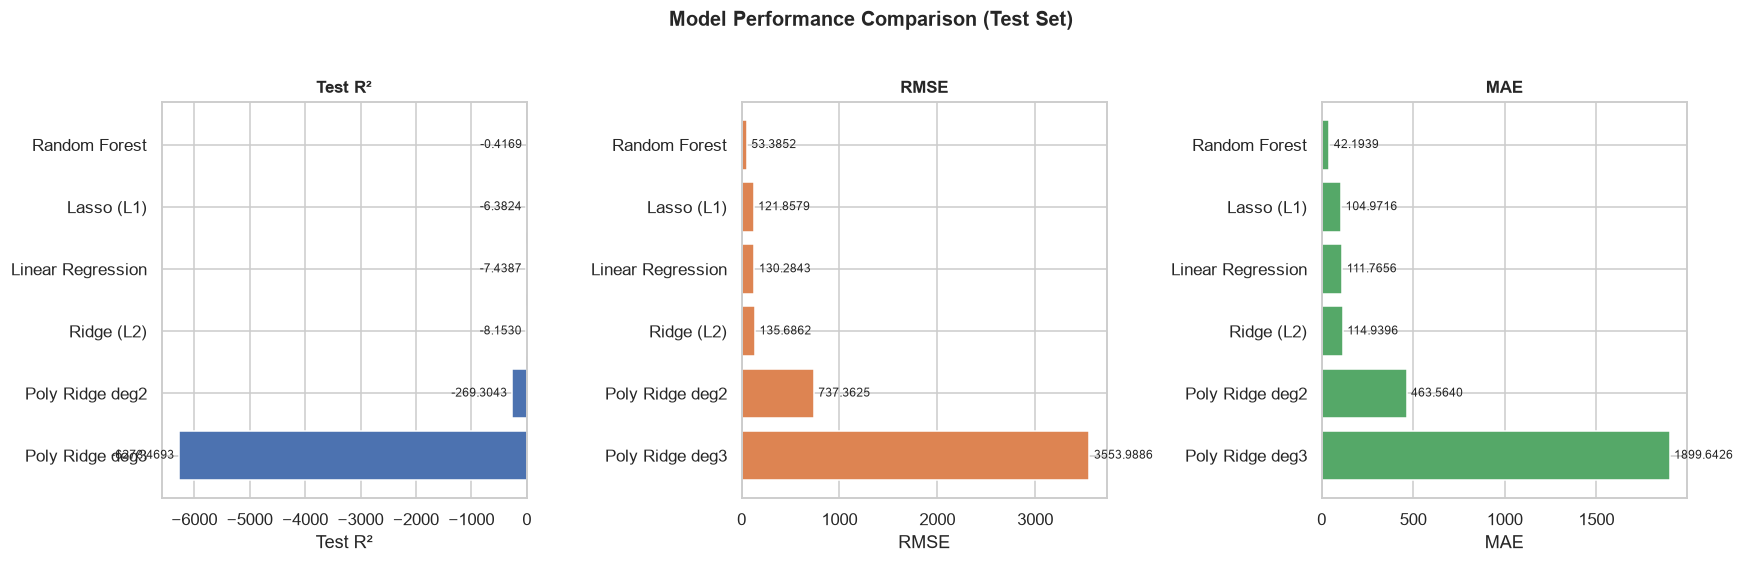

In [ ]:
# ── 8.3 Visual comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["Test R²", "RMSE", "MAE"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=(metric != "Test R²"))
    bars = ax.barh(sorted_df["Model"], sorted_df[metric], color=color, edgecolor="white")
    ax.bar_label(bars, fmt="{:.4f}", padding=3, fontsize=8)
    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle("Model Performance Comparison (Test Set)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


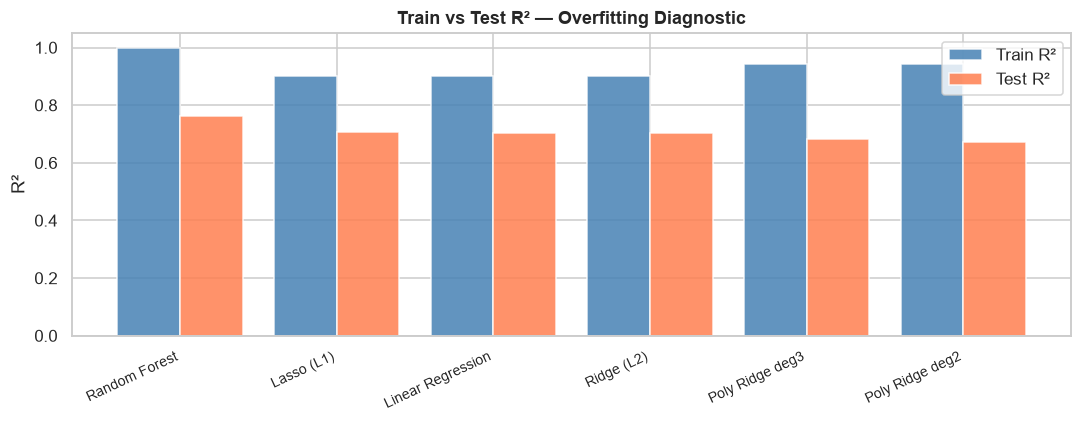


Overfit gaps (Train R² − Test R²):
  Random Forest            : +0.2378 ⚠️ overfit
  Lasso (L1)               : +0.1948 ⚠️ overfit
  Linear Regression        : +0.2004 ⚠️ overfit
  Ridge (L2)               : +0.2004 ⚠️ overfit
  Poly Ridge deg3          : +0.2606 ⚠️ overfit
  Poly Ridge deg2          : +0.2705 ⚠️ overfit


In [103]:
# ── 8.4 Train vs Test R² — overfitting check ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(len(results_df))
ax.bar(x_pos - 0.2, results_df["Train R²"], width=0.4, label="Train R²",
       color="steelblue", alpha=0.85)
ax.bar(x_pos + 0.2, results_df["Test R²"],  width=0.4, label="Test R²",
       color="coral",    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df["Model"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("R²")
ax.set_title("Train vs Test R² — Overfitting Diagnostic", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("\nOverfit gaps (Train R² − Test R²):")
for _, row in results_df.iterrows():
    flag = " ⚠️ overfit" if row["Overfit Gap"] > 0.05 else ""
    model_name = row["Model"]
    gap = row["Overfit Gap"]
    print(f"  {model_name:25s}: {gap:+.4f}{flag}")

In [104]:
print("Train R² for each model:")
for name, model in trained.items():
    tr2 = r2_score(y_train, model.predict(X_train_scaled))
    te2 = r2_score(y_test,  model.predict(X_test_scaled))
    print(f"  {name:25s}  Train={tr2:.4f}  Test={te2:.4f}")

Train R² for each model:
  Linear Regression          Train=0.9025  Test=0.7021
  Ridge (L2)                 Train=0.9025  Test=0.7021
  Lasso (L1)                 Train=0.9024  Test=0.7076
  Poly Ridge deg2            Train=0.9411  Test=0.6705
  Poly Ridge deg3            Train=0.9426  Test=0.6820
  Random Forest              Train=1.0000  Test=0.7622


In [94]:
print(f"Total quarters : {len(quarter_df)}")
print(f"Train quarters : {len(X_train)}")
print(f"Test quarters  : {len(X_test)}")
print(f"\nTrain y_diff  mean={y_train.mean():.2f}  std={y_train.std():.2f}  min={y_train.min():.2f}  max={y_train.max():.2f}")
print(f"Test  y_diff  mean={y_test.mean():.2f}  std={y_test.std():.2f}  min={y_test.min():.2f}  max={y_test.max():.2f}")

print(f"\nTrain R² for each model:")
for name, model in trained.items():
    tr2 = r2_score(y_train, model.predict(X_train_scaled))
    te2 = r2_score(y_test,  model.predict(X_test_scaled))
    print(f"  {name:25s}  Train={tr2:.4f}  Test={te2:.4f}")

Total quarters : 198
Train quarters : 158
Test quarters  : 40

Train y_diff  mean=2.60  std=42.47  min=-329.00  max=198.00
Test  y_diff  mean=0.57  std=50.17  min=-98.00  max=91.00

Train R² for each model:
  Linear Regression          Train=0.6538  Test=-5.9158
  Ridge (L2)                 Train=0.6459  Test=-16.4401
  Lasso (L1)                 Train=0.6530  Test=-7.3255
  Poly Ridge deg2            Train=0.3816  Test=-55.1637
  Poly Ridge deg3            Train=0.3681  Test=-249.5300
  Random Forest              Train=0.8549  Test=-0.0948


In [ ]:
# ── 8.5 Actual vs Predicted — best model ─────────────────────────────────────
best_name  = results_df.iloc[0]["Model"]
best_model = trained[best_name]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.35, s=12, color="steelblue")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted — {best_name}", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()


Total quarters : 198
Train quarters : 158  (years 1976–2015)
Test  quarters : 40   (years 2015–2025)

Train target  mean=96.5  std=113.9  min=1.0  max=525.0
Test  target  mean=371.5  std=45.4  min=267.0  max=461.0


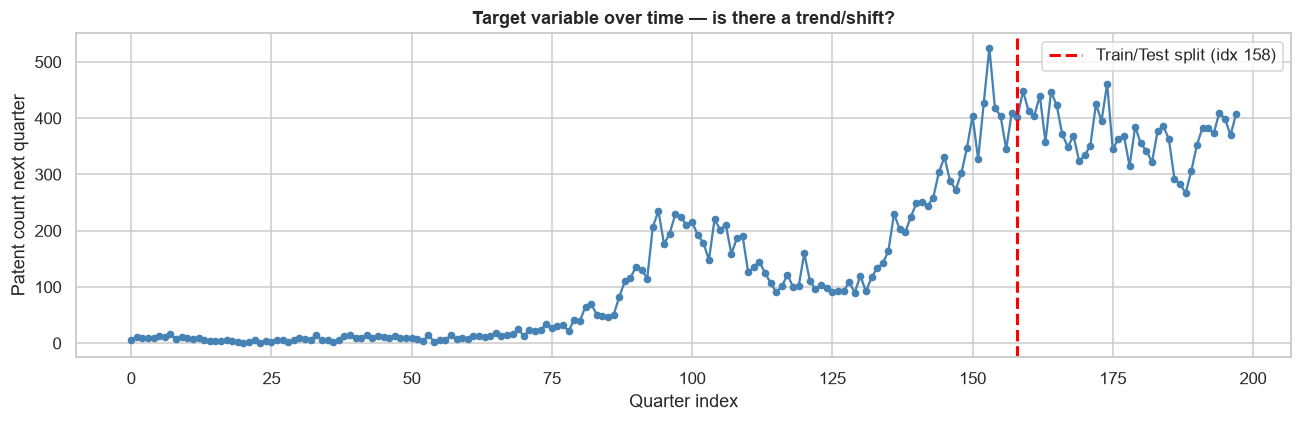

In [81]:
# ── Quarter-level data diagnostic ────────────────────────────────────────────
print(f"Total quarters : {len(quarter_df)}")
print(f"Train quarters : {len(X_train)}  (years {quarter_df['year'].iloc[:len(X_train)].min():.0f}–{quarter_df['year'].iloc[:len(X_train)].max():.0f})")
print(f"Test  quarters : {len(X_test)}   (years {quarter_df['year'].iloc[len(X_train):].min():.0f}–{quarter_df['year'].iloc[len(X_train):].max():.0f})")
print(f"\nTrain target  mean={y_train.mean():.1f}  std={y_train.std():.1f}  min={y_train.min():.1f}  max={y_train.max():.1f}")
print(f"Test  target  mean={y_test.mean():.1f}  std={y_test.std():.1f}  min={y_test.min():.1f}  max={y_test.max():.1f}")

# Plot target over time
plt.figure(figsize=(12, 4))
plt.plot(range(len(y)), y.values, marker="o", markersize=4, color="steelblue")
plt.axvline(len(X_train), color="red", linestyle="--", linewidth=2, label=f"Train/Test split (idx {len(X_train)})")
plt.xlabel("Quarter index")
plt.ylabel("Patent count next quarter")
plt.title("Target variable over time — is there a trend/shift?", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 8.6 Residual plot ────────────────────────────────────────────────────────
errors = y_test.values - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_best, errors, alpha=0.3, s=10, color="mediumpurple")
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residual vs Predicted", fontweight="bold")

sns.histplot(errors, bins=40, kde=True, color="mediumpurple", ax=axes[1])
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_title("Residual Distribution", fontweight="bold")

plt.tight_layout(); plt.show()
print(f"Mean residual : {errors.mean():.4f}  (≈ 0 → unbiased)")
print(f"Std of errors : {errors.std():.4f}")


---
## 🎛️ Section 9 — Hyperparameter Tuning

We run GridSearchCV with  (5 folds) — the temporally correct
cross-validation strategy for this dataset. Models tuned:

- **Ridge** — alpha (regularisation strength)
- **Lasso** — alpha
- **Polynomial Ridge deg2** — degree + alpha (prevents overfitting poly models)
- **Random Forest** — n_estimators, max_depth, min_samples_leaf

> 💡 We use  instead of  to prevent
> future data leaking into training folds.


In [106]:
# ── 9 — Hyperparameter Tuning (GroupKFold CV) ────────────────────────────────
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=5)
cv_groups = groups.iloc[train_idx].reset_index(drop=True)

# ── Ridge ─────────────────────────────────────────────────────────────────────
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]},
    cv=group_kfold.split(X_train_scaled, y_train, cv_groups),
    scoring="r2", n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
print(f"Ridge  best alpha={ridge_grid.best_params_}  CV R²={ridge_grid.best_score_:.4f}")

# ── Lasso ─────────────────────────────────────────────────────────────────────
lasso_grid = GridSearchCV(
    Lasso(max_iter=20000),
    param_grid={"alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]},
    cv=group_kfold.split(X_train_scaled, y_train, cv_groups),
    scoring="r2", n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)
print(f"Lasso  best alpha={lasso_grid.best_params_}  CV R²={lasso_grid.best_score_:.4f}")

# ── Random Forest (reduced grid for speed) ───────────────────────────────────
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators"    : [100, 200],
        "max_depth"       : [10, 20, None],
        "min_samples_leaf": [1, 5],
    },
    cv=group_kfold.split(X_train_scaled, y_train, cv_groups),
    scoring="r2", n_jobs=-1,
    verbose=2
)
rf_grid.fit(X_train_scaled, y_train)
print(f"RF     best params={rf_grid.best_params_}  CV R²={rf_grid.best_score_:.4f}")

Ridge  best alpha={'alpha': 500.0}  CV R²=0.8854
Lasso  best alpha={'alpha': 1.0}  CV R²=0.8827
Fitting 5 folds for each of 12 candidates, totalling 60 fits
RF     best params={'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}  CV R²=0.7732


In [108]:
# ── Tuned model evaluation ────────────────────────────────────────────────────
tuned_models = {
    "Ridge (tuned)"        : ridge_grid.best_estimator_,
    "Lasso (tuned)"        : lasso_grid.best_estimator_,
    "Random Forest (tuned)": rf_grid.best_estimator_,
}

print(f"{'Model':25s}  {'Train R²':>8}  {'Test R²':>8}  {'Gap':>8}  {'RMSE':>8}  {'MAE':>8}")
print("-" * 75)
for name, model in tuned_models.items():
    tr2  = r2_score(y_train, model.predict(X_train_scaled))
    te2  = r2_score(y_test,  model.predict(X_test_scaled))
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled)))
    mae  = mean_absolute_error(y_test, model.predict(X_test_scaled))
    print(f"  {name:25s}  {tr2:8.4f}  {te2:8.4f}  {tr2-te2:8.4f}  {rmse:8.2f}  {mae:8.2f}")

Model                      Train R²   Test R²       Gap      RMSE       MAE
---------------------------------------------------------------------------
  Ridge (tuned)                0.9017    0.7232    0.1785     59.36     47.31
  Lasso (tuned)                0.9003    0.7212    0.1791     59.57     47.27
  Random Forest (tuned)        0.9988    0.7634    0.2354     54.88     46.69


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

# ── 9.1 Ridge ────────────────────────────────────────────────────────────────
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]},
    cv=tscv, scoring="r2", n_jobs=-1, verbose=0
)
ridge_grid.fit(X_train_scaled, y_train)
print(f"Ridge   best alpha: {ridge_grid.best_params_}  CV R²: {ridge_grid.best_score_:.4f}")


In [ ]:
# ── 9.2 Lasso ────────────────────────────────────────────────────────────────
lasso_grid = GridSearchCV(
    Lasso(max_iter=20000),
    param_grid={"alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]},
    cv=tscv, scoring="r2", n_jobs=-1, verbose=0
)
lasso_grid.fit(X_train_scaled, y_train)
print(f"Lasso   best alpha: {lasso_grid.best_params_}  CV R²: {lasso_grid.best_score_:.4f}")


In [ ]:
# ── 9.3 Polynomial Ridge (degree 2) ──────────────────────────────────────────
# We regularise the polynomial model with Ridge to prevent overfitting.
poly_ridge_pipeline = Pipeline([
    ("poly",  PolynomialFeatures(include_bias=False)),
    ("ridge", Ridge())
])

poly_ridge_grid = GridSearchCV(
    poly_ridge_pipeline,
    param_grid={
        "poly__degree"  : [1, 2, 3],
        "ridge__alpha"  : [0.1, 1.0, 10.0, 100.0, 500.0]
    },
    cv=tscv, scoring="r2", n_jobs=-1, verbose=0
)
poly_ridge_grid.fit(X_train_scaled, y_train)
print(f"Poly Ridge best params: {poly_ridge_grid.best_params_}  CV R²: {poly_ridge_grid.best_score_:.4f}")


In [ ]:
# ── 9.4 Random Forest ────────────────────────────────────────────────────────
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators"   : [100, 200],
        "max_depth"      : [None, 10, 20, 30],
        "min_samples_leaf": [1, 2, 5],
    },
    cv=tscv, scoring="r2", n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_scaled, y_train)
print(f"RF best params: {rf_grid.best_params_}  CV R²: {rf_grid.best_score_:.4f}")


In [ ]:
# ── 9.5 Tuned model evaluation summary ───────────────────────────────────────
tuned_models = {
    "Ridge (tuned)"            : ridge_grid.best_estimator_,
    "Lasso (tuned)"            : lasso_grid.best_estimator_,
    "Poly Ridge (tuned)"       : poly_ridge_grid.best_estimator_,
    "Random Forest (tuned)"    : rf_grid.best_estimator_,
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred_tr = model.predict(X_train_scaled)
    y_pred_te = model.predict(X_test_scaled)
    tuned_results.append({
        "Model"      : name,
        "Train R²"   : round(r2_score(y_train, y_pred_tr), 4),
        "Test R²"    : round(r2_score(y_test,  y_pred_te), 4),
        "Overfit Gap": round(r2_score(y_train, y_pred_tr) - r2_score(y_test, y_pred_te), 4),
        "RMSE"       : round(float(np.sqrt(mean_squared_error(y_test, y_pred_te))), 4),
        "MAE"        : round(mean_absolute_error(y_test, y_pred_te), 4),
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("Test R²", ascending=False).reset_index(drop=True)
print("=" * 75)
print("                 TUNED MODEL RESULTS")
print("=" * 75)
print(tuned_df.to_string(index=False))


In [ ]:
# ── 9.6 Cross-validation scores for best tuned models ────────────────────────
print("
5-Fold TimeSeriesSplit CV R² scores:")
for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                 cv=tscv, scoring="r2", n_jobs=-1)
    print(f"  {name:30s}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


---
## 🏆 Section 10 — Final Model Decision & Interpretation

### How to read the results

| Observation | Interpretation |
|-------------|----------------|
| Poly deg2 R² ≈ Linear R² (Δ < 0.005) | Strong linearity — drop poly |
| Poly deg2 R² > Linear by ≥ 0.01 | Non-linearity exists — keep poly |
| RF >> linear/poly | Complex interactions — keep RF |
| High Train R², low Test R² | Overfitting — regularise or simplify |


In [ ]:
# ── 10.1 Final decision logic ────────────────────────────────────────────────
best_tuned_name  = tuned_df.iloc[0]["Model"]
best_tuned_model = tuned_models[best_tuned_name]

poly_tuned_r2 = tuned_df.loc[tuned_df["Model"] == "Poly Ridge (tuned)", "Test R²"].values[0]
ridge_tuned_r2 = tuned_df.loc[tuned_df["Model"] == "Ridge (tuned)",     "Test R²"].values[0]
rf_tuned_r2   = tuned_df.loc[tuned_df["Model"] == "Random Forest (tuned)", "Test R²"].values[0]

print("=" * 60)
print("          FINAL MODEL DECISION")
print("=" * 60)

poly_gain = poly_tuned_r2 - ridge_tuned_r2
rf_gain   = rf_tuned_r2   - ridge_tuned_r2

print(f"  Poly gain over Ridge  : {poly_gain:+.4f}")
print(f"  RF gain over Ridge    : {rf_gain:+.4f}")

if poly_gain < 0.005 and rf_gain < 0.005:
    print("
✅ Linear model suffices. Eliminate Poly AND RF.")
    print(f"   → Keep: Ridge (tuned)")
elif poly_gain < 0.005 and rf_gain >= 0.005:
    print("
⚠️  Polynomial adds nothing, but RF beats linear.")
    print("   → Keep: Random Forest (tuned). Drop Poly.")
elif poly_gain >= 0.005 and rf_gain < poly_gain:
    print("
⚠️  Non-linearity exists, captured by Poly Ridge.")
    print("   → Keep: Poly Ridge (tuned). RF optional.")
else:
    print("
❌ RF dominates. Strong non-linearity.")
    print("   → Keep: Random Forest (tuned).")

print(f"
  WINNER: {best_tuned_name}  (Test R² = {tuned_df.iloc[0]["Test R²"]:.4f})")
print("=" * 60)


In [ ]:
# ── 10.2 Feature importance / coefficients of winning model ─────────────────
if "Ridge" in best_tuned_name and "Poly" not in best_tuned_name:
    coef_df = pd.DataFrame({
        "Feature"    : features,
        "Coefficient": best_tuned_model.coef_
    }).reindex(
        pd.Series(best_tuned_model.coef_).abs().sort_values(ascending=False).index
    ).head(15)
    plt.figure(figsize=(9, 5))
    colors_coef = ["steelblue" if c >= 0 else "coral" for c in coef_df["Coefficient"]]
    sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette=colors_coef)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Top 15 Feature Coefficients (Ridge tuned)", fontweight="bold")
    plt.tight_layout(); plt.show()

elif "Random Forest" in best_tuned_name:
    imp_df = pd.DataFrame({
        "Feature"   : features,
        "Importance": best_tuned_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(15)
    plt.figure(figsize=(9, 5))
    sns.barplot(data=imp_df, x="Importance", y="Feature", color="steelblue")
    plt.title("Top 15 Feature Importances (Random Forest tuned)", fontweight="bold")
    plt.tight_layout(); plt.show()

elif "Poly" in best_tuned_name:
    poly_step  = best_tuned_model.named_steps["poly"]
    ridge_step = best_tuned_model.named_steps["ridge"]
    poly_feat_names = poly_step.get_feature_names_out(features)
    coef_df = pd.DataFrame({
        "Feature"    : poly_feat_names,
        "Coefficient": ridge_step.coef_
    }).reindex(
        pd.Series(ridge_step.coef_).abs().sort_values(ascending=False).index
    ).head(15)
    plt.figure(figsize=(9, 5))
    colors_coef = ["steelblue" if c >= 0 else "coral" for c in coef_df["Coefficient"]]
    sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette=colors_coef)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Top 15 Feature Coefficients (Poly Ridge tuned)", fontweight="bold")
    plt.tight_layout(); plt.show()


In [ ]:
# ── 10.3 Lasso feature selection: how many features zeroed out? ──────────────
lasso_best = lasso_grid.best_estimator_
n_zero = (lasso_best.coef_ == 0).sum()
n_total = len(lasso_best.coef_)
print(f"Lasso zeroed out {n_zero}/{n_total} features "
      f"({n_zero/n_total*100:.1f}%) — effective feature selection")

lasso_coef_df = pd.DataFrame({
    "Feature"    : features,
    "Coefficient": lasso_best.coef_
}).query("Coefficient != 0").sort_values("Coefficient", key=abs, ascending=False)
print(f"Non-zero features kept by Lasso:
{lasso_coef_df.to_string(index=False)}")


---
## 🔬 Section 11 — Domain-Specific Patent Prediction

Train one model per technology domain using the **best model type** found above.
Uses time-based split to avoid data leakage.


In [ ]:
DOMAINS = {
    "kw_5g"        : {"label": "5G",          "color": "#2f81f7"},
    "kw_ai_ml"     : {"label": "AI / ML",      "color": "#a371f7"},
    "kw_cloud_edge": {"label": "Cloud & Edge", "color": "#3fb950"},
    "kw_security"  : {"label": "Security",     "color": "#f85149"},
    "kw_iot"       : {"label": "IoT",          "color": "#d29922"},
    "kw_network"   : {"label": "Network",      "color": "#58a6ff"},
    "kw_energy"    : {"label": "Energy",       "color": "#56d364"},
    "kw_antenna"   : {"label": "Antenna",      "color": "#ff9a6c"},
    "kw_data"      : {"label": "Data",         "color": "#bc8cff"},
}

DOMAIN_FEATURES = ["year", "quarter", "lag1", "lag2", "lag4",
                   "roll4_mean", "roll4_std", "qoq", "yoy"]

def build_domain_ts(df, domain_col):
    ts = (df[df[domain_col] == 1]
          .groupby(["year", "quarter"]).size()
          .reset_index(name="patent_count")
          .sort_values(["year", "quarter"]).reset_index(drop=True))
    ts["lag1"]       = ts["patent_count"].shift(1)
    ts["lag2"]       = ts["patent_count"].shift(2)
    ts["lag4"]       = ts["patent_count"].shift(4)
    ts["roll4_mean"] = ts["patent_count"].shift(1).rolling(4).mean()
    ts["roll4_std"]  = ts["patent_count"].shift(1).rolling(4).std()
    ts["qoq"]        = ts["patent_count"].pct_change(1)
    ts["yoy"]        = ts["patent_count"].pct_change(4)
    ts["target"]     = ts["patent_count"].shift(-1)
    return ts.dropna().reset_index(drop=True)

DOMAIN_TS = {}
print(f"{"Domain":15s}  {"Quarters":>8}  {"Avg/Qtr":>7}")
print("-" * 38)
for col, info in DOMAINS.items():
    ts = build_domain_ts(df_raw, col)
    DOMAIN_TS[col] = ts
    print(f"  {info["label"]:13s}  {len(ts):8d}  {ts["patent_count"].mean():7.1f}")


In [ ]:
# ── 11.2 Train domain models using best global model type ────────────────────
def train_domain_model(ts, best_type="ridge"):
    split = int(len(ts) * 0.80)
    train, test = ts.iloc[:split], ts.iloc[split:]
    X_tr, y_tr = train[DOMAIN_FEATURES], train["target"]
    X_te, y_te = test[DOMAIN_FEATURES],  test["target"]

    sc = StandardScaler()
    Xtr = sc.fit_transform(X_tr)
    Xte = sc.transform(X_te)

    naive_mae = mean_absolute_error(y_te, test["lag1"])

    # Always try Ridge and Poly Ridge
    candidates = {
        "Ridge": Ridge(alpha=10.0),
        "Poly Ridge": Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)),
                                 ("ridge", Ridge(alpha=10.0))]),
    }
    best_c, best_pred, best_mae, best_cname = None, None, np.inf, ""
    for cname, cmodel in candidates.items():
        cmodel.fit(Xtr, y_tr)
        pred = cmodel.predict(Xte)
        mae  = mean_absolute_error(y_te, pred)
        if mae < best_mae:
            best_c, best_pred, best_mae, best_cname = cmodel, pred, mae, cname

    return {
        "model": best_c, "model_name": best_cname, "scaler": sc,
        "train": train, "test": test, "y_test": y_te, "y_pred": best_pred,
        "metrics": {
            "mae"       : round(best_mae, 2),
            "rmse"      : round(float(np.sqrt(mean_squared_error(y_te, best_pred))), 2),
            "r2"        : round(r2_score(y_te, best_pred), 3),
            "naive_mae" : round(naive_mae, 2),
        }
    }

DOMAIN_MODELS = {}
print(f"{"Domain":15s}  {"Model":12s}  {"MAE":>5}  {"Naive":>5}  {"Beats?":>8}  {"R²":>6}")
print("-" * 65)
for col, info in DOMAINS.items():
    result = train_domain_model(DOMAIN_TS[col])
    DOMAIN_MODELS[col] = result
    m = result["metrics"]
    beat = "✅ Yes" if m["mae"] < m["naive_mae"] else "❌ No "
    print(f"  {info["label"]:13s}  {result["model_name"]:12s}  "
          f"{m["mae"]:5.2f}  {m["naive_mae"]:5.2f}  {beat:>8}  {m["r2"]:6.3f}")


In [ ]:
# ── 11.3 Actual vs Predicted per domain ─────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()
for i, (col, info) in enumerate(DOMAINS.items()):
    res = DOMAIN_MODELS[col]
    ax  = axes[i]
    tr  = res["train"].copy(); te = res["test"].copy()
    tr["t"] = tr["year"] + (tr["quarter"] - 1) / 4
    te["t"] = te["year"] + (te["quarter"] - 1) / 4
    m = res["metrics"]
    ax.plot(tr["t"], tr["target"], color=info["color"], alpha=0.25, linewidth=1.5)
    ax.plot(te["t"], res["y_test"], color=info["color"], linewidth=2,
            marker="o", markersize=4, label="Actual")
    ax.plot(te["t"], res["y_pred"], color="white", linewidth=2,
            linestyle="--", marker="x", markersize=5, label="Predicted")
    ax.axvspan(te["t"].min(), te["t"].max(), alpha=0.07, color=info["color"])
    ax.set_title(f"{info["label"]}  [{res["model_name"]}]
"
                 f"MAE={m["mae"]} | Naive={m["naive_mae"]} | R²={m["r2"]}",
                 fontsize=8, fontweight="bold")
    ax.set_xlabel("Year", fontsize=7); ax.set_ylabel("Patents/Qtr", fontsize=7)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle("Domain Prediction: Actual vs Predicted (shaded = test period)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


In [ ]:
# ── 11.4 Next quarter prediction for every domain ────────────────────────────
print("=" * 55)
print("  NEXT QUARTER FORECASTS BY DOMAIN")
print("=" * 55)
for col, info in DOMAINS.items():
    ts     = DOMAIN_TS[col]
    result = DOMAIN_MODELS[col]
    last   = ts.iloc[-1]
    X_inp  = pd.DataFrame([{f: last[f] for f in DOMAIN_FEATURES}])
    X_sc   = result["scaler"].transform(X_inp)
    pred   = max(0, round(float(result["model"].predict(X_sc)[0]), 1))
    mae    = result["metrics"]["mae"]
    pred_q = int(last["quarter"]) % 4 + 1
    pred_y = int(last["year"]) + (1 if pred_q == 1 else 0)
    print(f"  {info["label"]:15s}: {pred:6.0f} ± {mae:.0f}  →  {pred_y} Q{pred_q}  [{result["model_name"]}]")
print("=" * 55)


---
## 📋 Final Summary

| Step | Action |
|------|--------|
| **Leakage fixed** | Excluded , , etc. |
| **XGBoost removed** | Replaced with Polynomial Regression (deg 2 & 3) |
| **Linearity test** | Section 8 compares poly gain over linear; auto-verdict printed |
| **Hyperparameter tuning** | GridSearchCV with TimeSeriesSplit for Ridge, Lasso, Poly Ridge, RF |
| **RF retention decision** | Based on whether RF test R² beats best linear/poly model |
| **Domain models** | Ridge vs Poly Ridge per domain — best wins |

> 🎓 If Poly deg2 R² ≈ Linear R² (gap < 0.005), the data is strongly linear.
> Regularised linear models (Ridge/Lasso) are sufficient — no need for RF or poly.
